# Dados faltantes e estimação por máxima verossimilhança

---

## Motivação
Dados faltantes são onipresentes em aplicações estatísticas reais. A resposta mais simples (descartar as observações incompletas e trabalhar apenas com os casos completos) desperdiça informação e pode introduzir viés. Uma resposta mais elegante, devida a T. W. Anderson (1957), mostra que a estrutura da distribuição normal multivariada pode ser explorada para obter estimadores de máxima verossimilhança (máxima verossimilhança) de forma surpreendentemente simples, sem qualquer algoritmo iterativo.

A ideia central é a fatoração da verossimilhança: em vez de maximizar a log-verossimilhança conjunta de todos os parâmetros simultaneamente, podemos reescrevê-la como soma de duas partes que envolvem conjuntos distintos de parâmetros, permitindo maximização independente de cada parte.

Neste estudo dirigido vamos redescobrir essa ideia usando dados reais de qualidade do ar. O conjunto de dados airquality, contém $n = 153$ medições diárias em Nova York (maio–setembro de 1973). As duas variáveis de interesse são:

- $Y_1 = \text{Solar.R}$: radiação solar (em Langleys, 08h–12h, Aeroporto JFK);
- $Y_2 = \text{Ozone}$: concentração média de ozônio (partes por bilhão (ppb), 13h–15h, Roosevelt Island).

In [797]:
data(airquality)

head(airquality)

,Ozone,Solar.R,Wind,Temp,Month,Day
,<int>,<int>,<dbl>,<int>,<int>,<int>
1,41,190,7.4,67,5,1
2,36,118,8.0,72,5,2
3,12,149,12.6,74,5,3
4,18,313,11.5,62,5,4
5,NA,NA,14.3,56,5,5
6,28,NA,14.9,66,5,6


---

## Análise Exploratória
Selecione as variáveis $\text{Solar.R}$ e $\text{Ozone}$ do dataset e classifique cada observação em um dos três padrões de dados faltantes: completo (ambas observadas), parcial ($Y_1$ observada, $Y_2$ faltante) e invertido ($Y_2$ observada, $Y_1$ faltante). Quantas observações há em cada padrão? O padrão é aproximadamente **monotônico**? Dizemos que um padrão é monotônico quando, para todo par de variáveis, qualquer observação com $Y_2$ faltante também tem $Y_1$ faltante – ou vice-versa.

Faça um gráfico de dispersão de $Y_2$ versus $Y_1$ para os casos completos e avalie visualmente a linearidade da relação. Experimente também o gráfico de $\ln(Y_2)$ versus $Y_1$. Qual transformação parece mais adequada para satisfazer a suposição de normalidade bivariada? Justifique com histogramas e/ou diagramas de nível bivariados.

Calcule a média amostral de $Y_1$ usando: (i) apenas os casos com $Y_1$ e $Y_2$ observados; (ii) todos os casos em que $Y_1$ está observada. As duas estimativas diferem? Qual tem menor erro padrão e por quê?

Por fim, suponha que a probabilidade de Y2 estar faltante depende apenas do valor observado de $Y_1$ (mecanismo Missing at Random, MAR). O que isso significa neste problema? Você acha plausível essa suposição para dados de ozônio e radiação solar? Por quê?

In [798]:
airquality$label <- ifelse(!is.na(airquality$Solar.R) & !is.na(airquality$Ozone), "complete",
                     ifelse(!is.na(airquality$Solar.R) & is.na(airquality$Ozone), "partial",
                     ifelse(is.na(airquality$Solar.R) & !is.na(airquality$Ozone), "inverted", "missing")))

table(airquality$label)


complete inverted  missing  partial 
     111        5        2       35 

como podemos ver na classificação, as amostras parciais são em maior número, então os dados são aproximadamente **monotônicos**, de forma que $Y_1$ é a variável mais completa

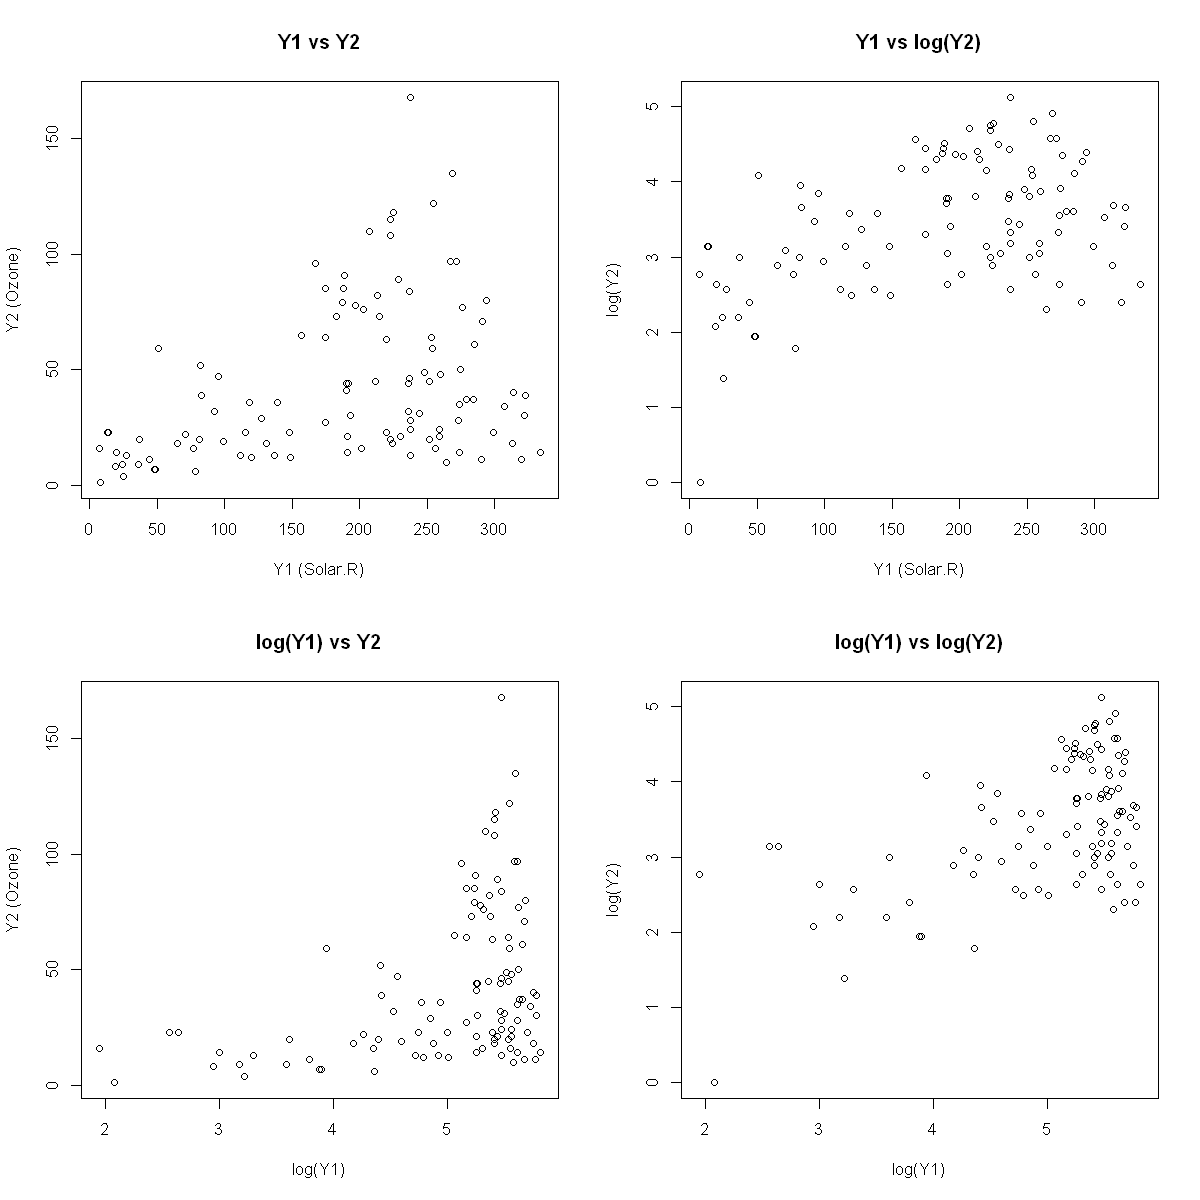

In [799]:
data(airquality)

options(repr.plot.width = 10, repr.plot.height = 10)
par(mfrow = c(2, 2), bg = "white")

plot(airquality$Solar.R, airquality$Ozone,
     xlab = "Y1 (Solar.R)", ylab = "Y2 (Ozone)", main = "Y1 vs Y2")

plot(airquality$Solar.R, log(airquality$Ozone),
     xlab = "Y1 (Solar.R)", ylab = "log(Y2)", main = "Y1 vs log(Y2)")

plot(log(airquality$Solar.R), airquality$Ozone,
     xlab = "log(Y1)", ylab = "Y2 (Ozone)", main = "log(Y1) vs Y2")

plot(log(airquality$Solar.R), log(airquality$Ozone),
     xlab = "log(Y1)", ylab = "log(Y2)", main = "log(Y1) vs log(Y2)")

par(mfrow = c(1, 1))  # volta pro layout normal depois

olhando os gráficos, não conseguimos afirmar com uma total certeza qual das transformações mais se parece com uma normal multivariada, então vamos aplicar outras visualizações

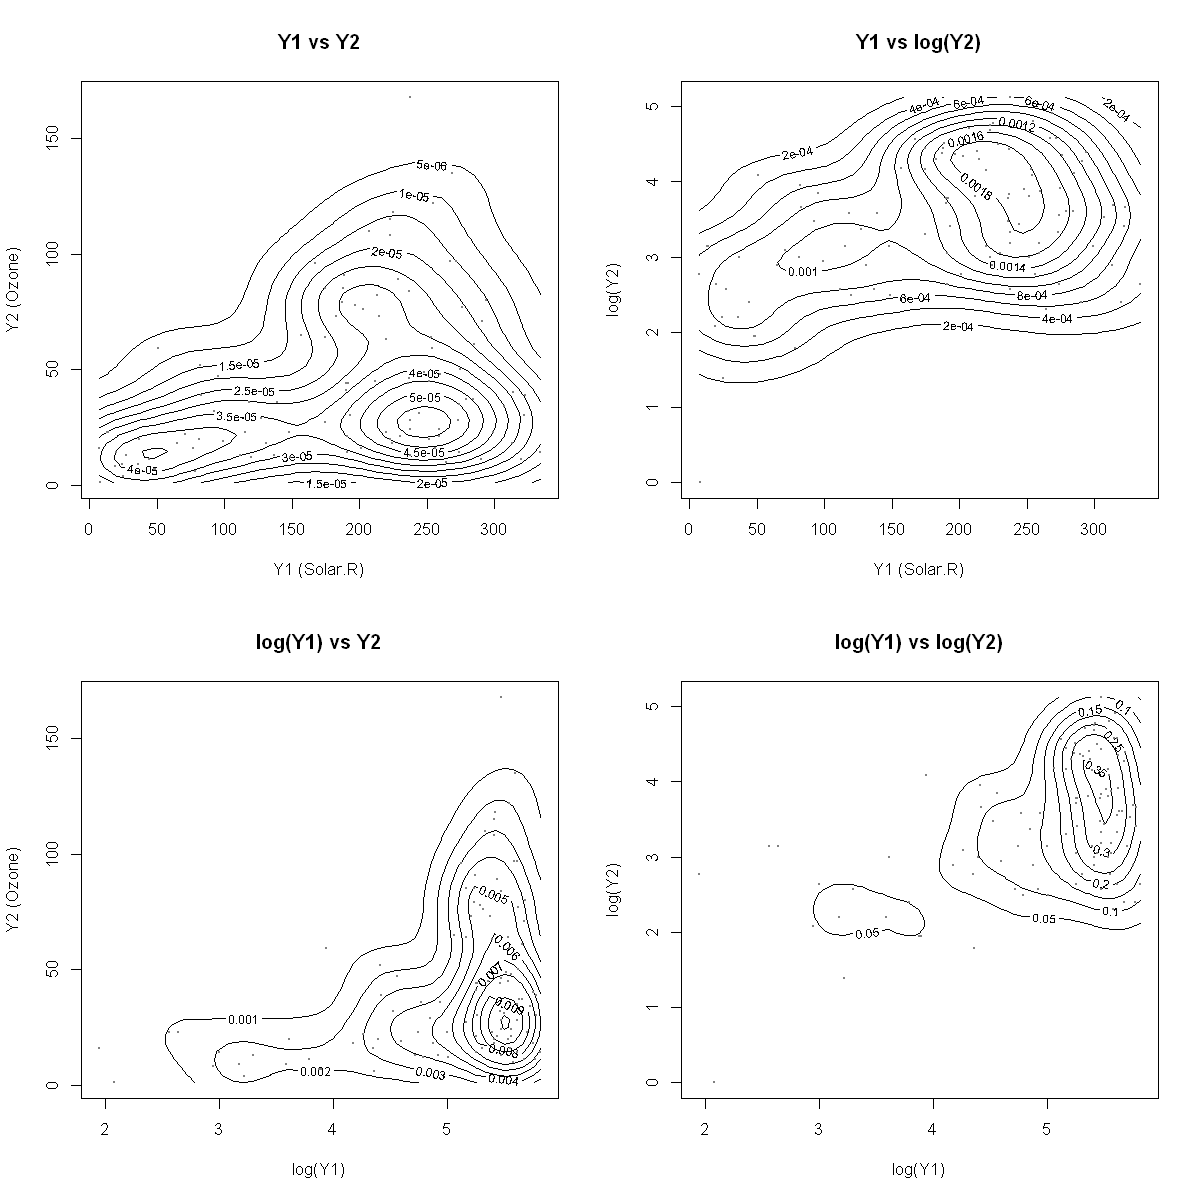

In [800]:
library(MASS)  # já vem com o R, não precisa instalar

data(airquality)
aq <- na.omit(airquality[, c("Solar.R", "Ozone")])  # diagrama de nível exige pares completos

par(mfrow = c(2, 2), bg = "white")

d1 <- kde2d(aq$Solar.R, aq$Ozone, n = 50)
contour(d1, xlab = "Y1 (Solar.R)", ylab = "Y2 (Ozone)", main = "Y1 vs Y2")
points(aq$Solar.R, aq$Ozone, pch = 20, cex = 0.5, col = "gray50")

d2 <- kde2d(aq$Solar.R, log(aq$Ozone), n = 50)
contour(d2, xlab = "Y1 (Solar.R)", ylab = "log(Y2)", main = "Y1 vs log(Y2)")
points(aq$Solar.R, log(aq$Ozone), pch = 20, cex = 0.5, col = "gray50")

d3 <- kde2d(log(aq$Solar.R), aq$Ozone, n = 50)
contour(d3, xlab = "log(Y1)", ylab = "Y2 (Ozone)", main = "log(Y1) vs Y2")
points(log(aq$Solar.R), aq$Ozone, pch = 20, cex = 0.5, col = "gray50")

d4 <- kde2d(log(aq$Solar.R), log(aq$Ozone), n = 50)
contour(d4, xlab = "log(Y1)", ylab = "log(Y2)", main = "log(Y1) vs log(Y2)")
points(log(aq$Solar.R), log(aq$Ozone), pch = 20, cex = 0.5, col = "gray50")

As visualizações ainda não são muito esclarecedoreas, elas dão indícios de que $Y_1$ e $\ln(Y_2)$ seguem uma normal multivariada, mas as outras também não estão tão distantes, então vamos tentar fazer um teste de hipótese e analisar as estatísticas de teste. Definimos então:
$$
    H_0: \text{Dados vem de uma normal multivariada}        \\
    H_1: \text{Dados não vem de uma normal multivariada}
$$
e vamos aplicar 3 testes em cada uma das transformações, o teste de Mardia, Royston e Henze-Zirkler

In [801]:
# Instalando o pacote de análise multivariada para o teste de normalidade

install.packages("MVN")

Warning message:
"o pacote 'MVN' está em uso e não será instalado"


In [802]:
library(MVN)
library(MASS)

In [803]:
aq <- na.omit(airquality[, c("Solar.R", "Ozone")])  # diagrama de nível exige pares completos

transformacoes <- list(
  "original" = aq,
  "log_y2"   = data.frame(Solar.R = aq$Solar.R, log_Ozone = log(aq$Ozone)),
  "log_y1"   = data.frame(log_Solar.R = log(aq$Solar.R), Ozone = aq$Ozone),
  "log_both" = data.frame(log_Solar.R = log(aq$Solar.R), log_Ozone = log(aq$Ozone))
)

resultados_mvn <- list()

for (nome in names(transformacoes)) {
  resultados_mvn[[nome]] <- list(
    mardia  = mvn(data = transformacoes[[nome]], mvn_test = "mardia")$multivariate_normality,
    hz      = mvn(data = transformacoes[[nome]], mvn_test = "hz")$multivariate_normality,
    royston = mvn(data = transformacoes[[nome]], mvn_test = "royston")$multivariate_normality
  )
}

In [804]:
ver_testes <- function(nome_transformacao) {
  if (!nome_transformacao %in% names(resultados_mvn)) {
    stop("Transformação não encontrada! Escolha entre: 'original', 'log_y2', 'log_y1' ou 'log_both'.")
  }
  
  cat("=========================================================\n")
  cat(" RESULTADOS DE NORMALIDADE MULTIVARIADA PARA:", toupper(nome_transformacao), "\n")
  cat("=========================================================\n\n")
  
  cat("--- Teste de Mardia (Skewness e Kurtosis) ---\n")
  print(resultados_mvn[[nome_transformacao]]$mardia)
  cat("\n---------------------------------------------------------\n")
  
  cat("--- Teste de Henze-Zirkler (HZ) ---\n")
  print(resultados_mvn[[nome_transformacao]]$hz)
  cat("\n---------------------------------------------------------\n")
  
  cat("--- Teste de Royston ---\n")
  print(resultados_mvn[[nome_transformacao]]$royston)
}

In [805]:
ver_testes("original")

 RESULTADOS DE NORMALIDADE MULTIVARIADA PARA: ORIGINAL 

--- Teste de Mardia (Skewness e Kurtosis) ---
             Test Statistic p.value     Method          MVN
1 Mardia Skewness    45.288  <0.001 asymptotic ✗ Not normal
2 Mardia Kurtosis    -0.573   0.567 asymptotic     ✓ Normal

---------------------------------------------------------
--- Teste de Henze-Zirkler (HZ) ---
           Test Statistic p.value     Method          MVN
1 Henze-Zirkler     4.063  <0.001 asymptotic ✗ Not normal

---------------------------------------------------------
--- Teste de Royston ---
     Test Statistic p.value     Method          MVN
1 Royston    48.389  <0.001 asymptotic ✗ Not normal


In [806]:
ver_testes("log_y1")

 RESULTADOS DE NORMALIDADE MULTIVARIADA PARA: LOG_Y1 

--- Teste de Mardia (Skewness e Kurtosis) ---
             Test Statistic p.value     Method          MVN
1 Mardia Skewness    86.315  <0.001 asymptotic ✗ Not normal
2 Mardia Kurtosis     3.092   0.002 asymptotic ✗ Not normal

---------------------------------------------------------
--- Teste de Henze-Zirkler (HZ) ---
           Test Statistic p.value     Method          MVN
1 Henze-Zirkler     6.021  <0.001 asymptotic ✗ Not normal

---------------------------------------------------------
--- Teste de Royston ---
     Test Statistic p.value     Method          MVN
1 Royston    76.684  <0.001 asymptotic ✗ Not normal


In [807]:
ver_testes("log_y2")

 RESULTADOS DE NORMALIDADE MULTIVARIADA PARA: LOG_Y2 

--- Teste de Mardia (Skewness e Kurtosis) ---
             Test Statistic p.value     Method          MVN
1 Mardia Skewness    15.355   0.004 asymptotic ✗ Not normal
2 Mardia Kurtosis    -0.509   0.611 asymptotic     ✓ Normal

---------------------------------------------------------
--- Teste de Henze-Zirkler (HZ) ---
           Test Statistic p.value     Method          MVN
1 Henze-Zirkler     2.363  <0.001 asymptotic ✗ Not normal

---------------------------------------------------------
--- Teste de Royston ---
     Test Statistic p.value     Method          MVN
1 Royston     24.18  <0.001 asymptotic ✗ Not normal


In [808]:
ver_testes("log_both")

 RESULTADOS DE NORMALIDADE MULTIVARIADA PARA: LOG_BOTH 

--- Teste de Mardia (Skewness e Kurtosis) ---
             Test Statistic p.value     Method          MVN
1 Mardia Skewness    52.994  <0.001 asymptotic ✗ Not normal
2 Mardia Kurtosis     3.459  <0.001 asymptotic ✗ Not normal

---------------------------------------------------------
--- Teste de Henze-Zirkler (HZ) ---
           Test Statistic p.value     Method          MVN
1 Henze-Zirkler      4.51  <0.001 asymptotic ✗ Not normal

---------------------------------------------------------
--- Teste de Royston ---
     Test Statistic p.value     Method          MVN
1 Royston    52.522  <0.001 asymptotic ✗ Not normal


Os únicos testes que encontraram alguma evidência de normalidade foram os testes mardia de kurtosis no dataset original e no com $Y_2$ transformado. Então podemos partir para uma abordagem mais visual usando os gráficos que vimos antes para escolher um para aplicar a hipótese de normalidade! Em minha opinião, o gráfico com $Y_2$ transformado é mais interessante, pois ele mostra uma melhor concentração dos pontos, enquanto no original os dados parecem vir de uma distribuição com duas médias distintas

In [809]:
# Calculando a média das amostras
data <- data.frame(Solar.R = airquality$Solar.R, log_Ozone = log(airquality$Ozone))
completos <- !is.na(data$Solar.R) & !is.na(data$log_Ozone)
y1_c <- data$Solar.R[completos]

n_c    <- length(y1_c)
media_c <- mean(y1_c)
dp_c   <- sd(y1_c)
ep_c   <- dp_c / sqrt(n_c)

y1_t <- data$Solar.R[!is.na(data$Solar.R)]

n_t    <- length(y1_t)
media_t <- mean(y1_t)
dp_t   <- sd(y1_t)
ep_t   <- dp_t / sqrt(n_t)

data.frame(
  grupo = c("completo", "todos"),
  n = c(n_c, n_t),
  media = c(media_c, media_t),
  desvio_padrao = c(dp_c, dp_t),
  erro_padrao = c(ep_c, ep_t)
)

grupo,n,media,desvio_padrao,erro_padrao
<chr>,<int>,<dbl>,<dbl>,<dbl>
completo,111,184.8018,91.15230,8.651794
todos,146,185.9315,90.05842,7.453288


de acordo com as estatísticas, o erro padrão da estimativa com todas as amostras é bem menor, o que é bem plausível, dado a distribuição da estatística da média:
$$
    \bar{Y}1 \sim N\left(\mu{Y_1}, \frac{\sigma_{Y_1}^2}{n}\right)
$$
ou seja, quanto maior o número de amostras, menor é o erro padrão da minha estimativa

In [810]:
head(airquality)

,Ozone,Solar.R,Wind,Temp,Month,Day
,<int>,<int>,<dbl>,<int>,<int>,<int>
1,41,190,7.4,67,5,1
2,36,118,8.0,72,5,2
3,12,149,12.6,74,5,3
4,18,313,11.5,62,5,4
5,NA,NA,14.3,56,5,5
6,28,NA,14.9,66,5,6


Com relação à premissa do MARS, resumindo-a matematicamente:
$$
    \mathbb{P}(\text{faltante}(Y_2)|Y_1,Y_2) = \mathbb{P}(\text{faltante}(Y_2)|Y_1)
$$
Em nosso contexto, eu prefiro argumentar que a premissa **MAR** é plausível, pois dias com radiação solar muito baixa costumam coincidir com condições climáticas adversas (nebulosidade densa, tempestades), e esse tipo de clima pode afetar a operação de equipamentos de monitoramento de forma mais ampla — não é implausível que falhas no sensor de ozônio fossem mais comuns nesses dias, criando uma correlação entre `Solar.R` baixo e `Ozone` faltante

---
## O estimador de casos completos
Seja $r$ o número de casos completos (com $Y_1$ e $Y_2$ ambos observados) e $n$ o total de observações com $Y_1$ observada. Usando apenas os $r$ casos completos, estime os cinco parâmetros da distribuição normal bivariada: $\hat{\mu}_1^{CC}$, $\hat{\mu}_2^{CC}$, $\hat{\sigma}_{11}^{CC}$, $\hat{\sigma}_{22}^{CC}$, $\hat{\sigma}_{12}^{CC}$. Use as fórmulas amostrais de máxima verossimilhança (divisão por r).

Mostre numericamente que o estimador de $\mu_1$ usando todos os $n$ casos tem erro padrão menor do que aquele baseado apenas nos $r$ casos completos. Qual é a razão $\sqrt{r/n}$ nos seus dados?

Sob MAR, o estimador CC para $\mu_2$ é não viesado? Apresente um argumento intuitivo e verifique empiricamente via simulação: gere 1.000 amostras de uma normal bivariada com os parâmetros estimados, aplique o mecanismo MAR artificialmente e compare as médias dos estimadores CC e do verdadeiro $\mu_2$. Construa um intervalo de confiança de $95$% para $\mu_2$ usando o estimador CC

In [811]:
airquality$logOzone <- log(airquality$Ozone)

completos <- !is.na(airquality$Solar.R) & !is.na(airquality$logOzone)
y1 <- airquality$Solar.R[completos]
y2 <- airquality$logOzone[completos]
n  <- length(y1)

mu1_cc <- mean(y1)
mu2_cc <- mean(y2)

sigma11_cc <- sqrt(sum((y1 - mu1_cc)^2) / n)
sigma22_cc <- sqrt(sum((y2 - mu2_cc)^2) / n)
sigma12_cc <- sum((y1 - mu1_cc) * (y2 - mu2_cc)) / n

# Resultado organizado
data.frame(
  parametro  = c("mu1_CC", "mu2_CC", "sigma11_CC", "sigma22_CC", "sigma12_CC"),
  estimativa = c(mu1_cc, mu2_cc, sigma11_cc, sigma22_cc, sigma12_cc)
)

parametro,estimativa
<chr>,<dbl>
mu1_CC,184.8018018
mu2_CC,3.4159273
sigma11_CC,90.7407772
sigma22_CC,0.8619586
sigma12_CC,35.6744082


mostrando o erro das estimativas da média usando os dois grupos (completo e todas as amostras)

In [812]:
# Calculando a média das amostras
data <- data.frame(Solar.R = airquality$Solar.R, log_Ozone = log(airquality$Ozone))
completos <- !is.na(data$Solar.R) & !is.na(data$log_Ozone)
y1_c <- data$Solar.R[completos]

n_c    <- length(y1_c)
media_c <- mean(y1_c)
dp_c   <- sd(y1_c)
ep_c   <- dp_c / sqrt(n_c)

y1_t <- data$Solar.R[!is.na(data$Solar.R)]

n_t    <- length(y1_t)
media_t <- mean(y1_t)
dp_t   <- sd(y1_t)
ep_t   <- dp_t / sqrt(n_t)

data.frame(
  grupo = c("completo", "todos"),
  n = c(n_c, n_t),
  media = c(media_c, media_t),
  desvio_padrao = c(dp_c, dp_t),
  erro_padrao = c(ep_c, ep_t)
)

grupo,n,media,desvio_padrao,erro_padrao
<chr>,<int>,<dbl>,<dbl>,<dbl>
completo,111,184.8018,91.15230,8.651794
todos,146,185.9315,90.05842,7.453288


como ja comentado anteriormente, por conta do erro padrão da distribuição da média depender inversamente da quantidade de dados, o resultado será menor quanto maior a quantidade de dados. Calculando razão $\sqrt{r/n}$

In [813]:
n_completos <- sum(!is.na(airquality$Solar.R) & !is.na(airquality$Ozone))
n_y1_observado <- sum(!is.na(airquality$Solar.R))

data.frame(
  categoria = c("completos", "y1_observado"),
  n = c(n_completos, n_y1_observado),
  sqrt_proporcao = c(sqrt(n_completos / nrow(airquality)), sqrt(n_y1_observado / nrow(airquality)))
)

categoria,n,sqrt_proporcao
<chr>,<int>,<dbl>
completos,111,0.8517571
y1_observado,146,0.9768564


mas será que, sob o MAR, o estimador de $\mu_2$ é viezado? Intuitivamente, podemos pensar que sim, já que, como o valor de $Y_2$ ser observado ou não depende do valor de $Y_1$, a média estimada não é necessariamente a média verdadeira de $Y_2$, pois como estamos observando apenas os valores em que **ambos** foram observados, eu não consigo olhar a distribuição de $Y_2$ marginalmente sem a influência da permissão de observabilidade imposta por $Y_1$

agora vou fazer a simulação com outras normais multivariadas

                                      estatistica            valor
                                   mu2 verdadeiro           3.4159
            media estimada (simulacao, 1000 reps)           3.5434
               vies estimado (media - verdadeiro)          0.12752
 DP da media nos dados reais (erro padrao, n=111)         0.082185
                  DP dos estimadores na simulacao         0.078905
                     IC medio das 1000 simulacoes (3.3841, 3.7028)
                     estatistica t (H0: vies = 0)           51.107
                           p-valor (H0: vies = 0)      5.3253e-281


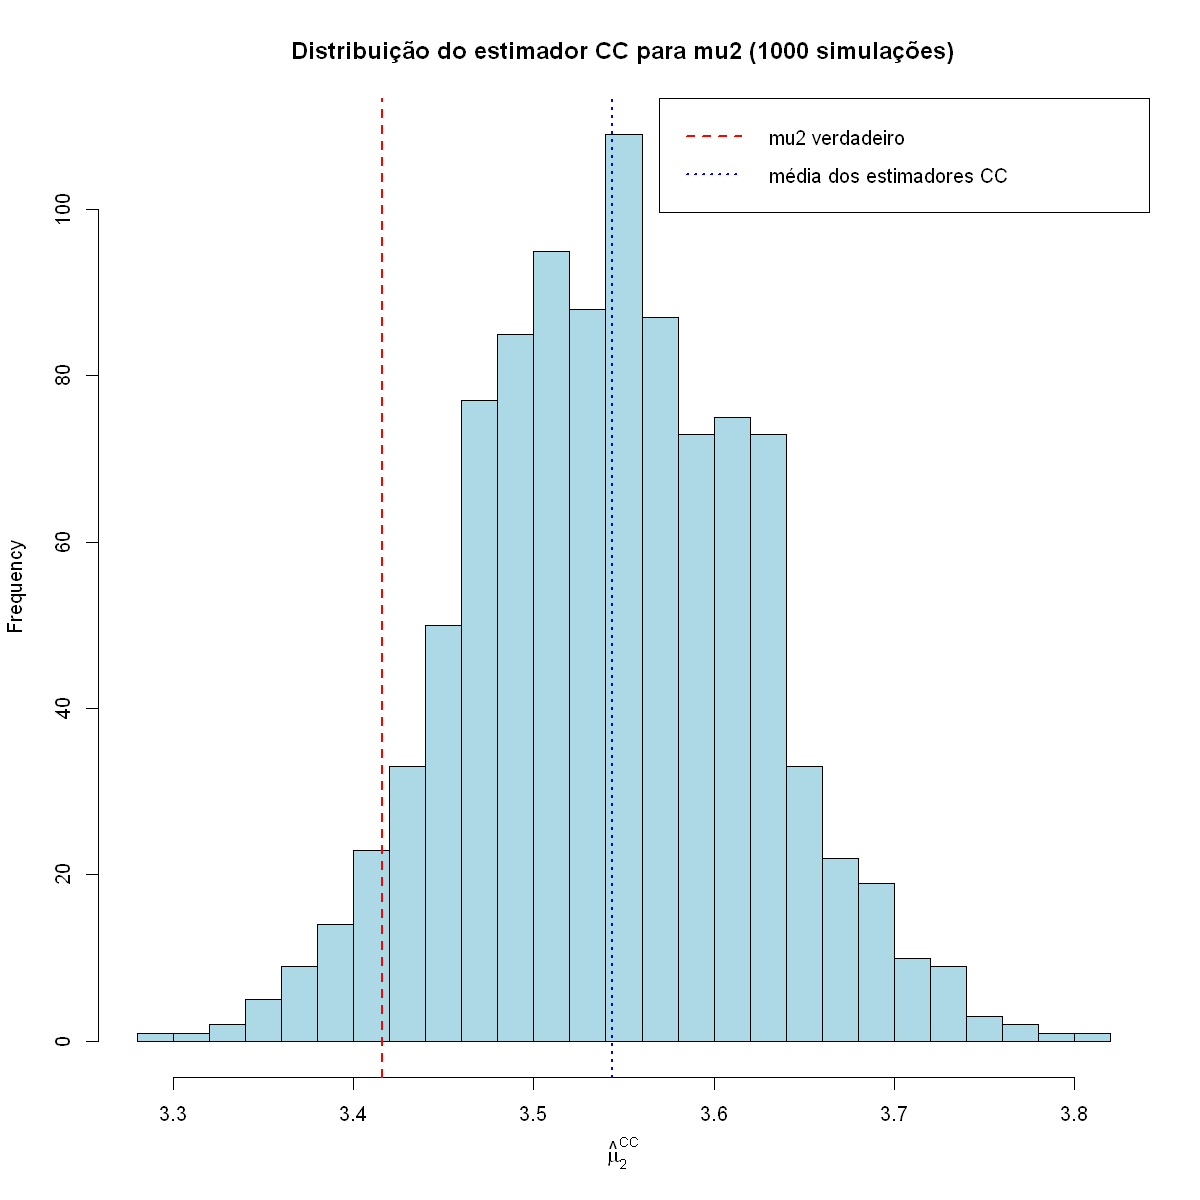

In [814]:
# Parâmetros "verdadeiros" da simulação = as estimativas CC já calculadas
mu_verdadeiro    <- c(mu1_cc, mu2_cc)
sigma11_cc       <- sigma11_cc^2   # correção: voltar de DP pra variância
sigma22_cc       <- sigma22_cc^2
Sigma_verdadeira <- matrix(c(sigma11_cc, sigma12_cc,
                             sigma12_cc, sigma22_cc), nrow = 2) + 1e-6 * diag(2)

set.seed(42)
n_sim <- 1000
N     <- 153

estimativas_cc <- numeric(n_sim)
ic_inf         <- numeric(n_sim)
ic_sup         <- numeric(n_sim)

for (i in 1:n_sim) {
  dados_sim <- mvrnorm(N, mu = mu_verdadeiro, Sigma = Sigma_verdadeira)

  y1_sim <- dados_sim[, 1]
  y2_sim <- dados_sim[, 2]

  z <- (y1_sim - mu_verdadeiro[1]) / sqrt(Sigma_verdadeira[1, 1])

  # Quanto maior y1, menor a chance de faltar y2 (MAR)
  p_faltante <- plogis(-1.15 - 1.5 * z)
  faltante_sim <- rbinom(N, size = 1, prob = p_faltante) == 1

  y2_cc_sim <- y2_sim[!faltante_sim]
  n_cc_sim  <- length(y2_cc_sim)

  media_cc_sim <- mean(y2_cc_sim)
  ep_cc_sim    <- sd(y2_cc_sim) / sqrt(n_cc_sim)

  estimativas_cc[i] <- media_cc_sim
  ic_inf[i] <- media_cc_sim - 1.96 * ep_cc_sim
  ic_sup[i] <- media_cc_sim + 1.96 * ep_cc_sim
}

# Teste de hipótese: H0: viés = 0
teste_vies <- t.test(estimativas_cc, mu = mu_verdadeiro[2])

# Erro padrão da média nos dados reais (n = 111, casos completos reais)
completos  <- !is.na(airquality$Solar.R) & !is.na(airquality$logOzone)
y2_real_cc <- airquality$logOzone[completos]
n_real_cc  <- length(y2_real_cc)
ep_real    <- sd(y2_real_cc) / sqrt(n_real_cc)

# Intervalo médio obtido nas simulações
ic_medio <- paste0(
  "(",
  signif(mean(ic_inf), 5),
  ", ",
  signif(mean(ic_sup), 5),
  ")"
)

# Resumo organizado
resumo <- data.frame(
  estatistica = c(
    "mu2 verdadeiro",
    "media estimada (simulacao, 1000 reps)",
    "vies estimado (media - verdadeiro)",
    "DP da media nos dados reais (erro padrao, n=111)",
    "DP dos estimadores na simulacao",
    "IC medio das 1000 simulacoes",
    "estatistica t (H0: vies = 0)",
    "p-valor (H0: vies = 0)"
  ),
  valor = c(
    signif(mu_verdadeiro[2], 5),
    signif(mean(estimativas_cc), 5),
    signif(mean(estimativas_cc) - mu_verdadeiro[2], 5),
    signif(ep_real, 5),
    signif(sd(estimativas_cc), 5),
    ic_medio,
    signif(unname(teste_vies$statistic), 5),
    signif(teste_vies$p.value, 5)
  )
)

print(resumo, row.names = FALSE)

# Visualização
par(bg = "white")
hist(
  estimativas_cc,
  breaks = 30,
  col = "lightblue",
  main = "Distribuição do estimador CC para mu2 (1000 simulações)",
  xlab = expression(hat(mu)[2]^{CC})
)

abline(v = mu_verdadeiro[2], col = "red", lwd = 2, lty = 2)
abline(v = mean(estimativas_cc), col = "blue", lwd = 2, lty = 3)

legend(
  "topright",
  legend = c("mu2 verdadeiro", "média dos estimadores CC"),
  col = c("red", "blue"),
  lty = c(2, 3),
  lwd = 2
)

como podemos ver, o p-valor é **muito** abaixo de $0.05$, o que objetivamente nos leva a rejeitar a hipótese ($H_0$) de que o viés seja $0$

## Fatoração da verossimilhança
Suponha que $(Y_{i1}, Y_{i2}) \overset{\text{iid}}{\sim} \text{Normal}_2(\mu, \Sigma)$, com $Y_{i2}$ faltante para $i=r+1,\ldots,n$ e MAR. A log-verossimilhança dos dados observados é:

$$
\ell(\mu,\Sigma \mid Y_{\text{obs}})
=
-\frac{r}{2}\ln |\Sigma|
-\frac{1}{2}\sum_{i=1}^{r}(y_i-\mu)^T\Sigma^{-1}(y_i-\mu)
-\frac{n-r}{2}\ln\sigma_{11}
-\frac{1}{2\sigma_{11}}
\sum_{i=r+1}^{n}(y_{i1}-\mu_1)^2.
\tag{1}
$$

Mostre que a distribuição conjunta de $(Y_{i1},Y_{i2})$ pode ser fatorada como:

$$
f(y_{i1},y_{i2}\mid\mu,\Sigma)
=
f_1(y_{i1}\mid\mu_1,\sigma_{11})
\cdot
f_2(y_{i2}\mid y_{i1},
\beta_{20\cdot1},
\beta_{21\cdot1},
\sigma_{22\cdot1}).
$$

e exiba as expressões para os parâmetros da regressão condicional,
$\beta_{20\cdot1}$, $\beta_{21\cdot1}$ e $\sigma_{22\cdot1}$.

Usando essa fatoração, mostre que a log-verossimilhança (1) pode ser reescrita como:

$$
\ell(\phi \mid Y_{\text{obs}})
=
\ell_1(\mu_1,\sigma_{11})
+
\ell_2(\beta_{20\cdot1},\beta_{21\cdot1},\sigma_{22\cdot1}),
$$

onde

$$
\phi
=
(\mu_1,\sigma_{11},
\beta_{20\cdot1},
\beta_{21\cdot1},
\sigma_{22\cdot1})^T
$$

é uma função bijetora de

$$
\theta
=
(\mu_1,\mu_2,
\sigma_{11},
\sigma_{12},
\sigma_{22})^T,
$$

e $\ell_1$ usa todos os $n$ valores de $Y_1$ enquanto $\ell_2$ usa apenas os $r$ casos completos.

Argumente que podemos maximizar $\ell_1$ e $\ell_2$ independentemente e derive os estimadores de máxima verossimilhança de $\phi$.

Mostre que o estimador de máxima verossimilhança de $\mu_2$ é:

$$
\hat{\mu}_2^{MV}
=
\bar{y}_2
+
\hat{\beta}_{21\cdot1}
(\hat{\mu}_1-\bar{x}_1),
\tag{2}
$$

onde $\bar{y}_2$ e $\bar{x}_1$ são as médias amostrais dos $r$ casos completos,

$$
\hat{\mu}_1
=
\frac{1}{n}\sum_{i=1}^{n}y_{i1}
$$

usa todos os $n$ casos, e

$$
\hat{\beta}_{21\cdot1}
=
\frac{s_{12}}{s_{11}}
$$

é estimado nos $r$ casos completos.

Implemente o estimador (2) no R e compare com
$\hat{\mu}_2^{CC}$.
O que muda e por quê?

### 1. Distribuição conjunta

Temos

$$
(Y_{i1},Y_{i2})^T
\sim
N_2(\mu,\Sigma)
$$

com

$$
\mu=
\begin{pmatrix}
\mu_1\\
\mu_2
\end{pmatrix}
$$

e

$$
\Sigma=
\begin{pmatrix}
\sigma_{11} & \sigma_{12}\\
\sigma_{12} & \sigma_{22}
\end{pmatrix}.
$$

A densidade conjunta é

$$
f(y_{i1},y_{i2})
=
\frac{
1
}{
2\pi
\sqrt{\sigma_{11}\sigma_{22}-\sigma_{12}^2}
}
\exp
\left\{
-\frac{
\sigma_{22}(y_{i1}-\mu_1)^2
-2\sigma_{12}(y_{i1}-\mu_1)(y_{i2}-\mu_2)
+\sigma_{11}(y_{i2}-\mu_2)^2
}
{
2(\sigma_{11}\sigma_{22}-\sigma_{12}^2)
}
\right\}.
$$

---

### 2. Fatoração da normal bivariada

Usamos

$$
f(y_{i1},y_{i2})
=
f(y_{i1})
f(y_{i2}\mid y_{i1}).
$$

#### Marginal de $Y_{i1}$

$$
Y_{i1}
\sim
N(\mu_1,\sigma_{11})
$$

logo

$$
f_1(y_{i1})
=
\frac{1}{\sqrt{2\pi\sigma_{11}}}
\exp
\left[
-\frac{
(y_{i1}-\mu_1)^2
}{
2\sigma_{11}
}
\right].
$$

---

#### Condicional de $Y_{i2}\mid Y_{i1}$

Pela teoria da normal multivariada,

$$
Y_{i2}\mid Y_{i1}=y_{i1}
\sim
N
\Big(
\mu_2+
\frac{\sigma_{12}}{\sigma_{11}}
(y_{i1}-\mu_1),
\;
\sigma_{22}
-
\frac{\sigma_{12}^2}{\sigma_{11}}
\Big).
$$

Reescrevendo a média na forma de regressão:

$$
E(Y_{i2}\mid Y_{i1})
=
\beta_{20\cdot1}
+
\beta_{21\cdot1}Y_{i1},
$$

onde

$$
\beta_{21\cdot1}
=
\frac{\sigma_{12}}{\sigma_{11}},
$$

$$
\beta_{20\cdot1}
=
\mu_2
-
\frac{\sigma_{12}}{\sigma_{11}}
\mu_1,
$$

e

$$
\sigma_{22\cdot1}
=
\sigma_{22}
-
\frac{\sigma_{12}^2}{\sigma_{11}}.
$$

Portanto

$$
Y_{i2}\mid Y_{i1}
\sim
N(
\beta_{20\cdot1}
+
\beta_{21\cdot1}Y_{i1},
\,
\sigma_{22\cdot1}
).
$$

Logo

$$
f(y_{i1},y_{i2})
=
f_1(y_{i1})
f_2(y_{i2}\mid y_{i1}).
$$

---

### 3. Reparametrização

Definimos

$$
\phi=
(
\mu_1,
\sigma_{11},
\beta_{20\cdot1},
\beta_{21\cdot1},
\sigma_{22\cdot1}
)^T.
$$

As transformações são

$$
\beta_{21\cdot1}
=
\frac{\sigma_{12}}{\sigma_{11}},
$$

$$
\beta_{20\cdot1}
=
\mu_2-\beta_{21\cdot1}\mu_1,
$$

$$
\sigma_{22\cdot1}
=
\sigma_{22}
-\frac{\sigma_{12}^2}{\sigma_{11}}.
$$

E a inversa é

$$
\sigma_{12}
=
\beta_{21\cdot1}\sigma_{11},
$$

$$
\mu_2
=
\beta_{20\cdot1}
+
\beta_{21\cdot1}\mu_1,
$$

$$
\sigma_{22}
=
\sigma_{22\cdot1}
+
\beta_{21\cdot1}^2\sigma_{11}.
$$

Logo a transformação é bijetora.

---

### 4. Fatoração da verossimilhança observada

Para os $r$ casos completos:

$$
f(y_{i1},y_{i2})
=
f_1(y_{i1})
f_2(y_{i2}\mid y_{i1}).
$$

Para os casos incompletos:

$$
f(y_{i1})
=
f_1(y_{i1}).
$$

Assim,

$$
L(\phi)
=
\prod_{i=1}^{n}
f_1(y_{i1})
\;
\prod_{i=1}^{r}
f_2(y_{i2}\mid y_{i1}).
$$

Tomando log:

$$
\ell(\phi)
=
\ell_1(\mu_1,\sigma_{11})
+
\ell_2(
\beta_{20\cdot1},
\beta_{21\cdot1},
\sigma_{22\cdot1}
).
$$

---

### 5. Expressão de $\ell_1$

$$
\ell_1
=
-\frac{n}{2}\log\sigma_{11}
-\frac{
1
}{
2\sigma_{11}
}
\sum_{i=1}^{n}
(y_{i1}-\mu_1)^2.
$$

Utiliza todos os $n$ valores observados de $Y_1$.

---

### 6. Expressão de $\ell_2$

$$
\ell_2
=
-\frac{r}{2}\log\sigma_{22\cdot1}
-\frac{
1
}{
2\sigma_{22\cdot1}
}
\sum_{i=1}^{r}
\left(
y_{i2}
-
\beta_{20\cdot1}
-
\beta_{21\cdot1}y_{i1}
\right)^2.
$$

Utiliza apenas os $r$ casos completos.

---

### 7. Maximização de $\ell_1$

Derivando em relação a $\mu_1$:

$$
\frac{\partial\ell_1}{\partial\mu_1}=0
$$

obtemos

$$
\hat{\mu}_1
=
\frac1n
\sum_{i=1}^{n}
y_{i1}.
$$

Derivando em relação a $\sigma_{11}$:

$$
\hat{\sigma}_{11}
=
\frac1n
\sum_{i=1}^{n}
(y_{i1}-\hat{\mu}_1)^2.
$$

---

### 8. Maximização de $\ell_2$

A maximização coincide com a regressão linear normal.

Definindo

$$
\bar{x}_1
=
\frac1r
\sum_{i=1}^{r}y_{i1},
$$

$$
\bar{y}_2
=
\frac1r
\sum_{i=1}^{r}y_{i2},
$$

$$
s_{11}
=
\frac1r
\sum_{i=1}^{r}
(y_{i1}-\bar{x}_1)^2,
$$

$$
s_{12}
=
\frac1r
\sum_{i=1}^{r}
(y_{i1}-\bar{x}_1)
(y_{i2}-\bar{y}_2),
$$

temos

$$
\hat{\beta}_{21\cdot1}
=
\frac{s_{12}}{s_{11}},
$$

$$
\hat{\beta}_{20\cdot1}
=
\bar{y}_2
-
\hat{\beta}_{21\cdot1}\bar{x}_1.
$$

E

$$
\hat{\sigma}_{22\cdot1}
=
\frac1r
\sum_{i=1}^{r}
\left(
y_{i2}
-
\hat{\beta}_{20\cdot1}
-
\hat{\beta}_{21\cdot1}y_{i1}
\right)^2.
$$

---

### 9. Estimador MV de $\mu_2$

Da transformação inversa,

$$
\mu_2
=
\beta_{20\cdot1}
+
\beta_{21\cdot1}\mu_1.
$$

Substituindo os estimadores MV:

$$
\hat{\mu}_2
=
\hat{\beta}_{20\cdot1}
+
\hat{\beta}_{21\cdot1}
\hat{\mu}_1.
$$

Como

$$
\hat{\beta}_{20\cdot1}
=
\bar{y}_2
-
\hat{\beta}_{21\cdot1}\bar{x}_1,
$$

segue que

$$
\hat{\mu}_2
=
\bar{y}_2
+
\hat{\beta}_{21\cdot1}
(\hat{\mu}_1-\bar{x}_1).
$$

que é exatamente a expressão pedida.

In [815]:
completo <- !is.na(airquality$Solar.R) & !is.na(airquality$logOzone)
y1_obs   <- !is.na(airquality$Solar.R)

y1_r <- airquality$Solar.R[completo]
y2_r <- airquality$logOzone[completo]
y1_n <- airquality$Solar.R[y1_obs]
 
r <- length(y1_r)
n <- length(y1_n)

cat(sprintf("r (casos completos): %d\n", r))
cat(sprintf("n (Y1 observada):    %d\n\n", n))

r (casos completos): 111
n (Y1 observada):    146



In [816]:
mu1_cc <- mean(y1_r)
mu2_cc <- mean(y2_r)

s11_cc <- sum((y1_r - mu1_cc)^2) / r
s22_cc <- sum((y2_r - mu2_cc)^2) / r
s12_cc <- sum((y1_r - mu1_cc) * (y2_r - mu2_cc)) / r

In [817]:
mu1_mv  <- mean(y1_n)
sigma11 <- sum((y1_n - mu1_mv)^2) / n

x_bar   <- mean(y1_r)
y2_bar  <- mean(y2_r)

beta21  <- s12_cc / s11_cc
beta20  <- y2_bar - beta21 * x_bar

residuos   <- y2_r - (beta20 + beta21 * y1_r)
sigma22_1  <- sum(residuos^2) / r

mu2_mv  <- y2_bar + beta21 * (mu1_mv - x_bar)

In [818]:
sigma12_mv <- beta21 * sigma11
sigma22_mv <- sigma22_1 + beta21^2 * sigma11

In [819]:
cat("===========================================================\n")
cat("  Comparação: Estimador CC vs. EMV de Anderson (1957)\n")
cat("===========================================================\n\n")
 
comparacao <- data.frame(
  parametro    = c("mu1", "mu2", "sigma11", "sigma22", "sigma12"),
  CC           = c(mu1_cc,   mu2_cc,   s11_cc,    s22_cc,    s12_cc),
  MV_Anderson  = c(mu1_mv,   mu2_mv,   sigma11,   sigma22_mv, sigma12_mv),
  diferenca_absoluta    = abs(c(mu1_mv - mu1_cc,
                   mu2_mv - mu2_cc,
                   sigma11 - s11_cc,
                   sigma22_mv - s22_cc,
                   sigma12_mv - s12_cc))
)
 
print(comparacao, digits = 5, row.names = FALSE)

  Comparação: Estimador CC vs. EMV de Anderson (1957)

 parametro         CC MV_Anderson diferenca_absoluta
       mu1  184.80180   185.93151         1.1297e+00
       mu2    3.41593     3.42082         4.8946e-03
   sigma11 8233.88865  8054.96791         1.7892e+02
   sigma22    0.74297     0.73961         3.3586e-03
   sigma12   35.67441    34.89921         7.7520e-01


In [820]:
cat("\n-----------------------------------------------------------\n")
cat("  Foco em μ₂ (log(Ozone)):\n")
cat(sprintf("  μ̂₂^CC  = %.5f  (usando apenas r = %d casos completos)\n", mu2_cc, r))
cat(sprintf("  μ̂₂^MV  = %.5f  (usando n = %d obs. de Y1 via eq. 2)\n", mu2_mv, n))
cat(sprintf("  Diferença (MV - CC) = %.5f\n", mu2_mv - mu2_cc))
cat("-----------------------------------------------------------\n\n")
 
cat("Decomposição da diferença μ̂₂^MV - μ̂₂^CC:\n")
cat(sprintf("  β̂₂₁·₁             = %.5f\n", beta21))
cat(sprintf("  μ̂₁^MV (n=%d)     = %.5f\n", n, mu1_mv))
cat(sprintf("  x̄₁    (r=%d)     = %.5f\n", r, x_bar))
cat(sprintf("  Correção (β̂·Δμ₁) = β̂₂₁·₁ × (μ̂₁ − x̄₁) = %.5f × %.5f = %.5f\n",
            beta21, mu1_mv - x_bar, beta21 * (mu1_mv - x_bar)))


-----------------------------------------------------------
  Foco em μ₂ (log(Ozone)):
  μ̂₂^CC  = 3.41593  (usando apenas r = 111 casos completos)
  μ̂₂^MV  = 3.42082  (usando n = 146 obs. de Y1 via eq. 2)
  Diferença (MV - CC) = 0.00489
-----------------------------------------------------------

Decomposição da diferença μ̂₂^MV - μ̂₂^CC:
  β̂₂₁·₁             = 0.00433
  μ̂₁^MV (n=146)     = 185.93151
  x̄₁    (r=111)     = 184.80180
  Correção (β̂·Δμ₁) = β̂₂₁·₁ × (μ̂₁ − x̄₁) = 0.00433 × 1.12971 = 0.00489


## Extra: Quantificação da Incerteza (40 pontos)

O estimador de Anderson é uma função não linear de estatísticas de dois subconjuntos de dados. Implemente o seguinte procedimento de bootstrap paramétrico para quantificar sua incerteza:

1. Estime os parâmetros $\hat{\mu}$ e $\hat{\Sigma}$ pelo estimador de Anderson.

2. Simule $B = 2.000$ amostras de tamanho $n$ de $\text{normal}_2(\hat{\mu}, \hat{\Sigma})$.

3. Em cada amostra, aplique o mesmo padrão de dados faltantes observado nos dados reais.

4. Aplique o estimador de Anderson a cada amostra e guarde $\hat{\mu}_2^{(b)}$.

5. Reporte o desvio padrão de $\{\hat{\mu}_2^{(b)}\}$ como estimativa do erro padrão.

Compare os intervalos de confiança de 95% para $\mu_2$ obtidos por:

1. estimador CC (Questão 2);
2. estimador de Anderson com bootstrap paramétrico;
3. estimador de Anderson com bootstrap não paramétrico (reamostrar linhas com reposição).

Qual intervalo é mais estreito? Isso era esperado?

A eficiência relativa do estimador de Anderson frente ao CC depende de quais quantidades do modelo? Em que regime — correlação alta ou baixa entre $Y_1$ e $Y_2$; fração de dados faltantes alta ou baixa — o ganho é maior?

Elabore sua resposta com uma pequena simulação.

In [821]:
set.seed(42)

N_total  <- nrow(airquality)
 
idx_completo  <- which(!is.na(airquality$Solar.R) & !is.na(airquality$logOzone))
idx_parcial   <- which(!is.na(airquality$Solar.R) &  is.na(airquality$logOzone))
idx_invertido <- which( is.na(airquality$Solar.R) & !is.na(airquality$logOzone))
idx_ausente   <- which( is.na(airquality$Solar.R) &  is.na(airquality$logOzone))

In [822]:
miss_y2 <- is.na(airquality$logOzone)
miss_y1 <- is.na(airquality$Solar.R)
 
r <- length(idx_completo)
n_y1 <- sum(!miss_y1)

In [823]:
cat("============================================================\n")
cat("  A. Padrão de dados faltantes nos dados reais\n")
cat("============================================================\n")
cat(sprintf("  Completos  (Y1 e Y2 obs.): %d\n",  r))
cat(sprintf("  Parciais   (Y1 obs., Y2 NA): %d\n", length(idx_parcial)))
cat(sprintf("  Invertidos (Y1 NA, Y2 obs.): %d\n", length(idx_invertido)))
cat(sprintf("  Ambos NA:  %d\n",  length(idx_ausente)))
cat(sprintf("  n (Y1 observada): %d\n\n", n_y1))

  A. Padrão de dados faltantes nos dados reais
  Completos  (Y1 e Y2 obs.): 111
  Parciais   (Y1 obs., Y2 NA): 35
  Invertidos (Y1 NA, Y2 obs.): 5
  Ambos NA:  2
  n (Y1 observada): 146



In [824]:
y1_r <- airquality$Solar.R[idx_completo]
y2_r <- airquality$logOzone[idx_completo]
y1_n <- airquality$Solar.R[!miss_y1]

mu1_cc  <- mean(y1_r)
mu2_cc  <- mean(y2_r)
s11_cc  <- mean((y1_r - mu1_cc)^2)
s22_cc  <- mean((y2_r - mu2_cc)^2)
s12_cc  <- mean((y1_r - mu1_cc) * (y2_r - mu2_cc))
 
mu1_mv   <- mean(y1_n)
sigma11  <- mean((y1_n - mu1_mv)^2)
x_bar    <- mu1_cc
y2_bar   <- mu2_cc
beta21   <- s12_cc / s11_cc
beta20   <- y2_bar - beta21 * x_bar
res      <- y2_r - (beta20 + beta21 * y1_r)
sigma22_1 <- mean(res^2)
mu2_mv   <- y2_bar + beta21 * (mu1_mv - x_bar)
 
sigma12_mv <- beta21 * sigma11
sigma22_mv <- sigma22_1 + beta21^2 * sigma11
 
mu_hat    <- c(mu1_mv, mu2_mv)
Sigma_hat <- matrix(c(sigma11,    sigma12_mv,
                       sigma12_mv, sigma22_mv), 2, 2)

In [825]:
cat("  EMV de Anderson:\n")
cat(sprintf("  μ̂₁ = %.5f,  μ̂₂ = %.5f\n", mu1_mv, mu2_mv))
cat(sprintf("  Σ̂ = [%.4f  %.4f]\n      [%.4f  %.4f]\n\n",
            Sigma_hat[1,1], Sigma_hat[1,2],
            Sigma_hat[2,1], Sigma_hat[2,2]))

  EMV de Anderson:
  μ̂₁ = 185.93151,  μ̂₂ = 3.42082
  Σ̂ = [8054.9679  34.8992]
      [34.8992  0.7396]



In [826]:
anderson_mu2 <- function(y1_all, y2_all, m1, m2) {
  comp <- !m1 & !m2           # casos completos
  y1_obs_all <- y1_all[!m1]   # Y1 observada em todos os padrões
 
  if (sum(comp) < 3 || length(y1_obs_all) < 3) return(NA_real_)
 
  y1c  <- y1_all[comp];  y2c  <- y2_all[comp]
  mu1c <- mean(y1c);     mu2c <- mean(y2c)
  s11  <- mean((y1c - mu1c)^2)
  s12  <- mean((y1c - mu1c) * (y2c - mu2c))
 
  if (abs(s11) < 1e-12) return(NA_real_)
 
  b21  <- s12 / s11
  mu1_all <- mean(y1_obs_all)
  mu2c + b21 * (mu1_all - mu1c)
}

In [827]:
B <- 2000
boot_param <- numeric(B)
 
for (b in seq_len(B)) {
  sim      <- mvrnorm(N_total, mu = mu_hat, Sigma = Sigma_hat)
  y1b      <- sim[, 1]
  y2b      <- sim[, 2]
  # Padrão idêntico ao observado: mesmas linhas com NA
  boot_param[b] <- anderson_mu2(y1b, y2b, miss_y1, miss_y2)
}
 
ep_param  <- sd(boot_param, na.rm = TRUE)
ic_param  <- quantile(boot_param, c(0.025, 0.975), na.rm = TRUE)

In [828]:
cat("============================================================\n")
cat("  B. Bootstrap PARAMÉTRICO (B =", B, ")\n")
cat("============================================================\n")
cat(sprintf("  EP bootstrap paramétrico = %.5f\n", ep_param))
cat(sprintf("  IC 95%%: [%.5f, %.5f]   largura = %.5f\n\n",
            ic_param[1], ic_param[2], diff(ic_param)))

  B. Bootstrap PARAMÉTRICO (B = 2000 )
  EP bootstrap paramétrico = 0.08083
  IC 95%: [3.25950, 3.57726]   largura = 0.31775



In [829]:
boot_npar <- numeric(B)
 
aq_boot <- data.frame(y1 = airquality$Solar.R,
                       y2 = airquality$logOzone)
 
for (b in seq_len(B)) {
  idx_b  <- sample(seq_len(N_total), size = N_total, replace = TRUE)
  df_b   <- aq_boot[idx_b, ]
  m1b    <- is.na(df_b$y1)
  m2b    <- is.na(df_b$y2)
  boot_npar[b] <- anderson_mu2(df_b$y1, df_b$y2, m1b, m2b)
}
 
ep_npar  <- sd(boot_npar, na.rm = TRUE)
ic_npar  <- quantile(boot_npar, c(0.025, 0.975), na.rm = TRUE)

In [830]:
cat("============================================================\n")
cat("  C. Bootstrap NÃO PARAMÉTRICO (B =", B, ")\n")
cat("============================================================\n")
cat(sprintf("  EP bootstrap não paramétrico = %.5f\n", ep_npar))
cat(sprintf("  IC 95%%: [%.5f, %.5f]   largura = %.5f\n\n",
            ic_npar[1], ic_npar[2], diff(ic_npar)))

  C. Bootstrap NÃO PARAMÉTRICO (B = 2000 )
  EP bootstrap não paramétrico = 0.08139
  IC 95%: [3.26091, 3.58338]   largura = 0.32247



In [831]:
s22_cc_corr <- var(y2_r)
ep_cc       <- sqrt(s22_cc_corr / r)
t_crit      <- qt(0.975, df = r - 1)
ic_cc       <- mu2_cc + c(-1, 1) * t_crit * ep_cc

In [832]:
cat("============================================================\n")
cat("  D. IC ANALÍTICO — Estimador CC\n")
cat("============================================================\n")
cat(sprintf("  EP analítico CC = %.5f\n", ep_cc))
cat(sprintf("  IC 95%%: [%.5f, %.5f]   largura = %.5f\n\n",
            ic_cc[1], ic_cc[2], diff(ic_cc)))

  D. IC ANALÍTICO — Estimador CC
  EP analítico CC = 0.08218
  IC 95%: [3.25306, 3.57880]   largura = 0.32574



In [833]:
cat("============================================================\n")
cat("  E. COMPARAÇÃO DOS INTERVALOS DE CONFIANÇA 95% para μ₂\n")
cat("============================================================\n")

tab_ic <- data.frame(
  metodo      = c("CC (analítico)",
                  "Anderson – boot. paramétrico",
                  "Anderson – boot. não paramétrico"),
  estimativa  = c(mu2_cc, mu2_mv, mu2_mv),
  EP          = c(ep_cc,  ep_param, ep_npar),
  IC_inf      = c(ic_cc[1],    ic_param[1],  ic_npar[1]),
  IC_sup      = c(ic_cc[2],    ic_param[2],  ic_npar[2]),
  largura     = c(diff(ic_cc), diff(ic_param), diff(ic_npar))
)
 
print(tab_ic, digits = 5, row.names = FALSE)

  E. COMPARAÇÃO DOS INTERVALOS DE CONFIANÇA 95% para μ₂
                           metodo estimativa       EP IC_inf IC_sup largura
                   CC (analítico)     3.4159 0.082185 3.2531 3.5788 0.32574
     Anderson – boot. paramétrico     3.4208 0.080826 3.2595 3.5773 0.31775
 Anderson – boot. não paramétrico     3.4208 0.081388 3.2609 3.5834 0.32247


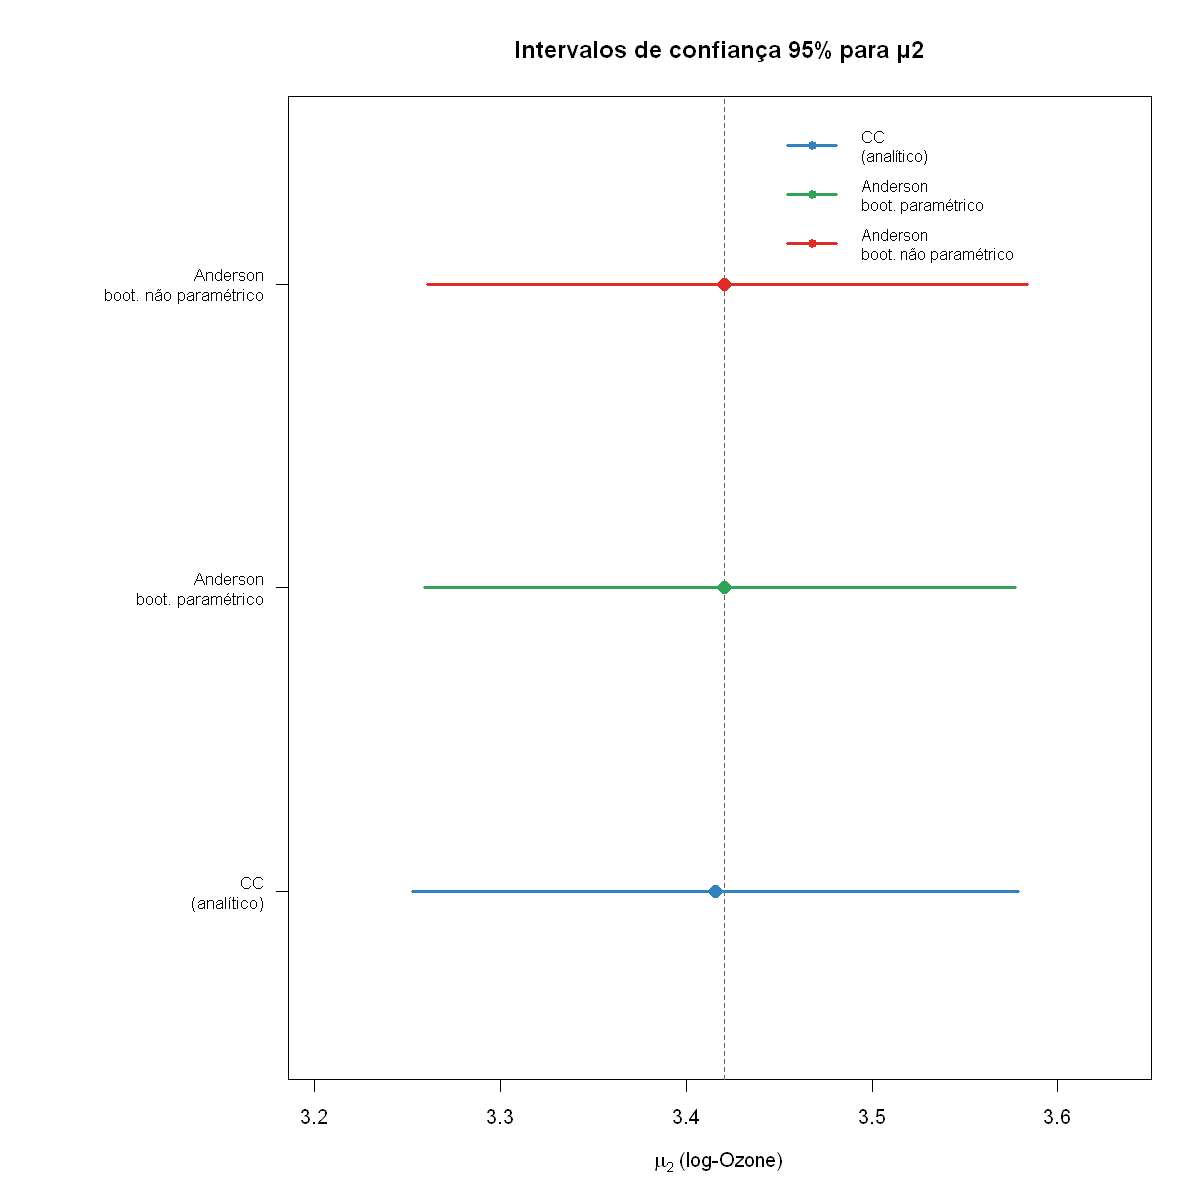

In [834]:
par(bg = "white", mar = c(5, 12, 4, 2))
 
cores   <- c("#3182bd", "#31a354", "#de2d26")
metodos <- c("CC\n(analítico)",
             "Anderson\nboot. paramétrico",
             "Anderson\nboot. não paramétrico")
 
plot(NULL, xlim = range(c(ic_cc, ic_param, ic_npar)) + c(-0.05, 0.05),
     ylim = c(0.5, 3.5), yaxt = "n",
     xlab = expression(mu[2] ~ "(log-Ozone)"),
     ylab = "", main = "Intervalos de confiança 95% para μ2")
 
axis(2, at = 1:3, labels = metodos, las = 1, cex.axis = 0.85)
abline(v = mu2_mv, col = "gray40", lty = 2, lwd = 1.5)
 
for (k in 1:3) {
  inf_k <- c(ic_cc[1], ic_param[1], ic_npar[1])[k]
  sup_k <- c(ic_cc[2], ic_param[2], ic_npar[2])[k]
  est_k <- c(mu2_cc, mu2_mv, mu2_mv)[k]
 
  segments(inf_k, k, sup_k, k, lwd = 3, col = cores[k])
  points(est_k, k, pch = 19, cex = 1.4, col = cores[k])
}
 
legend("topright", legend = metodos, col = cores,
       lwd = 3, pch = 19, bty = "n", cex = 0.8)
 
par(mar = c(5, 4, 4, 2), bg = "white")   # reset

Podemos observar que os intervalos de confiança são **muito** parecidos, o que indica que os estimadores estão tendo uma confiança muito parecida, mas isso é esperado? Para responder essa pergunta, vamos rodar uma simulação e comparar os estimadores

In [835]:
cat("\n============================================================\n")
cat("  F. SIMULAÇÃO — Eficiência Relativa (MSE_CC / MSE_MV)\n")
cat("     em função de ρ e da fração de dados faltantes\n")
cat("============================================================\n\n")

n_ef   <- 200        # tamanho de amostra fixo
S      <- 1000       # réplicas por célula da grade
mu_sim <- c(0, 0)    # sem perda de generalidade
 
# Grade de parâmetros
rhos    <- c(0.1, 0.3, 0.5, 0.7, 0.9)
p_misss <- c(0.10, 0.25, 0.40, 0.55)
 
resultados_ef <- expand.grid(rho = rhos, p_miss = p_misss)
resultados_ef$EF_relativa <- NA_real_
 
set.seed(123)
 
for (k in seq_len(nrow(resultados_ef))) {
  rho_k   <- resultados_ef$rho[k]
  p_miss_k <- resultados_ef$p_miss[k]
 
  Sigma_k <- matrix(c(1, rho_k, rho_k, 1), 2, 2)  # variâncias = 1
  n_miss_k <- round(n_ef * p_miss_k)               # qtd de Y2 ausentes
 
  mse_cc <- numeric(S)
  mse_mv <- numeric(S)
 
  for (s in seq_len(S)) {
    # Gerar dados completos
    dados <- mvrnorm(n_ef, mu = mu_sim, Sigma = Sigma_k)
    y1    <- dados[, 1]
    y2    <- dados[, 2]
 
    # MAR: probabilidade de Y2 faltar aumenta com Y1 baixo
    # P(miss_i | y1_i) ∝ logistic(-y1_i) — dependência suave
    prob_miss <- plogis(-y1)
    prob_miss <- prob_miss / sum(prob_miss) * n_miss_k
    prob_miss <- pmin(prob_miss, 1)
 
    miss_idx <- sample(n_ef, size = n_miss_k,
                       prob = prob_miss / sum(prob_miss))
 
    m1_s <- rep(FALSE, n_ef)              # Y1 sempre observada
    m2_s <- rep(FALSE, n_ef)
    m2_s[miss_idx] <- TRUE
 
    # Estimador CC
    comp_s    <- !m2_s
    y1c_s     <- y1[comp_s];  y2c_s <- y2[comp_s]
    mu2_cc_s  <- mean(y2c_s)
 
    # Estimador Anderson
    mu2_mv_s  <- anderson_mu2(y1, y2, m1_s, m2_s)
 
    mse_cc[s] <- (mu2_cc_s - 0)^2
    mse_mv[s] <- (mu2_mv_s - 0)^2
  }
 
  resultados_ef$EF_relativa[k] <- mean(mse_cc) / mean(mse_mv)
}
 
# Tabela resumo
tab_ef <- reshape(resultados_ef,
                  idvar     = "rho",
                  timevar   = "p_miss",
                  direction = "wide")
colnames(tab_ef) <- c("rho",
                       paste0("p_miss=", p_misss))
print(tab_ef, digits = 4, row.names = FALSE)


  F. SIMULAÇÃO — Eficiência Relativa (MSE_CC / MSE_MV)
     em função de ρ e da fração de dados faltantes

 rho p_miss=0.1 p_miss=0.25 p_miss=0.4 p_miss=0.55
 0.1      1.006       1.016      1.017       0.977
 0.3      1.032       1.216      1.422       1.840
 0.5      1.097       1.706      2.711       3.986
 0.7      1.178       2.480      4.600       8.349
 0.9      1.434       3.398      8.528      18.651


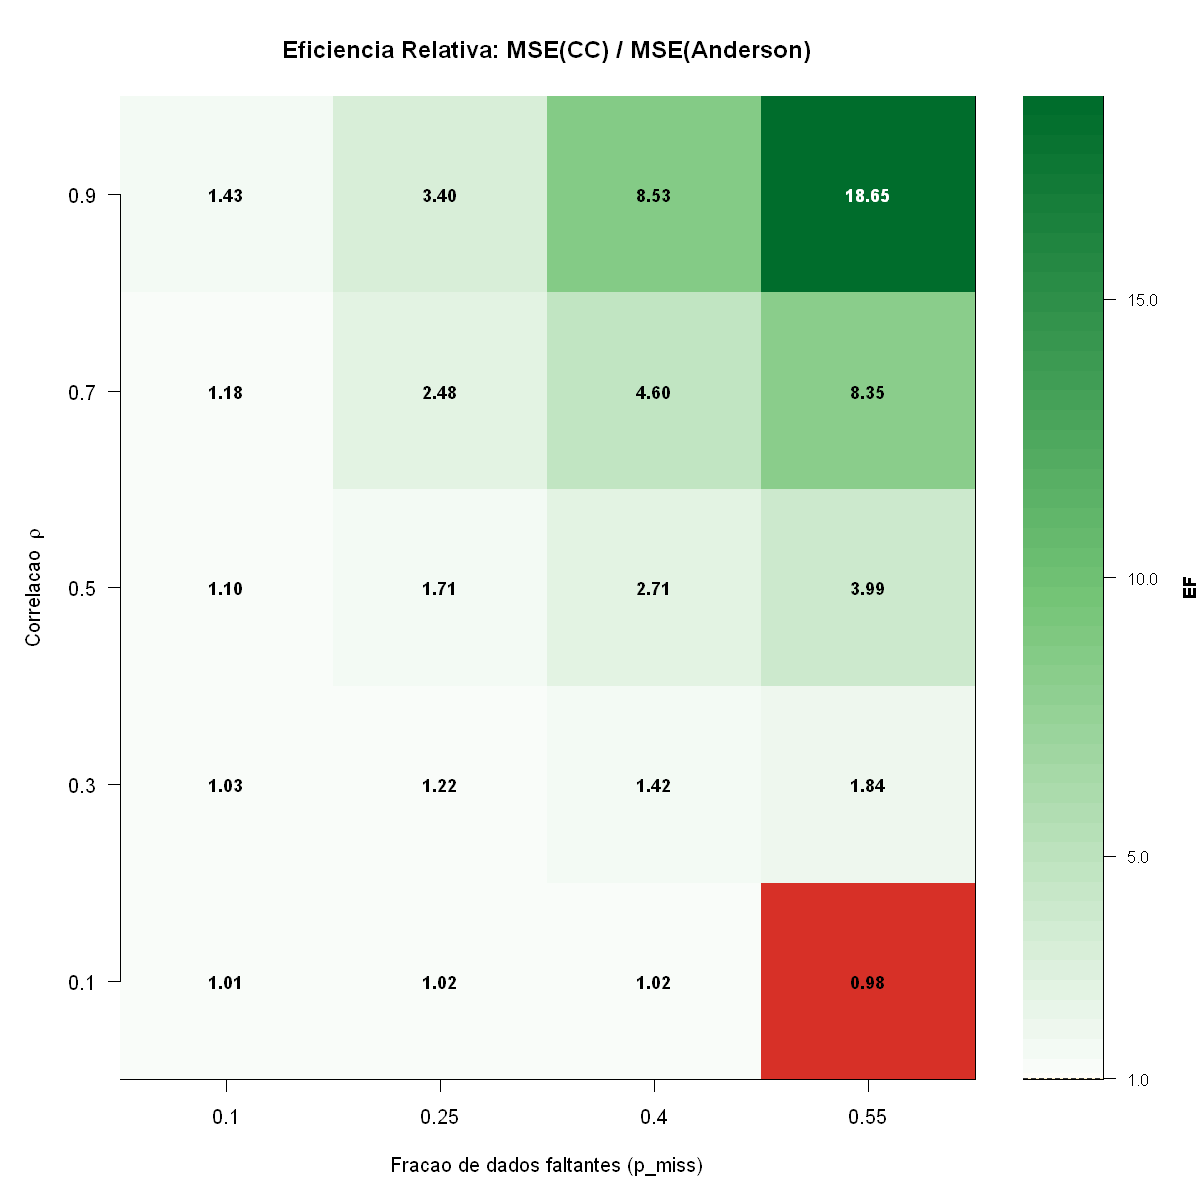

In [836]:
val_min <- min(mat_ef)
val_max <- max(mat_ef)

n_abaixo <- 50
n_acima  <- 50

pal_abaixo <- colorRampPalette(c("#d73027", "#fee08b", "white"))(n_abaixo + 1)
pal_acima  <- colorRampPalette(c("white", "#74c476", "#006d2c"))(n_acima  + 1)
pal_full   <- c(pal_abaixo[-length(pal_abaixo)], pal_acima[-1])

breaks_full <- c(
  seq(val_min, 1,       length.out = n_abaixo + 1),
  seq(1,       val_max, length.out = n_acima  + 1)[-1]
)

layout(matrix(c(1, 2), nrow = 1), widths = c(5, 1))

# --- Painel 1: heatmap contínuo ---
par(mar = c(5, 5, 4, 1), bg = "white")

image(x = seq_along(p_misss), y = seq_along(rhos),
      z = t(mat_ef),
      col = pal_full, breaks = breaks_full,
      xaxt = "n", yaxt = "n",
      xlab = "Fracao de dados faltantes (p_miss)",
      ylab = expression("Correlacao " ~ rho),
      main = "Eficiencia Relativa: MSE(CC) / MSE(Anderson)")

axis(1, at = seq_along(p_misss), labels = p_misss)
axis(2, at = seq_along(rhos),    labels = rhos, las = 1)

for (i in seq_along(p_misss)) {
  for (j in seq_along(rhos)) {
    val_ij  <- mat_ef[j, i]
    cor_txt <- ifelse(val_ij > val_max * 0.55 | val_ij < 0.85, "white", "black")
    text(i, j, sprintf("%.2f", val_ij), cex = 0.9, font = 2, col = cor_txt)
  }
}

# --- Painel 2: colorbar CORRIGIDA ---
par(mar = c(5, 1, 4, 4), bg = "white")

# CORREÇÃO AQUI: Calculamos o ponto médio de cada intervalo definido em breaks_full
# Isso garante que cada cor seja desenhada exatamente no lugar correto da escala real
bar_y <- (breaks_full[-1] + breaks_full[-length(breaks_full)]) / 2

image(x = 1, y = bar_y,
      z = matrix(bar_y, nrow = 1),
      col  = pal_full,       # Usa a mesma paleta do heatmap
      breaks = breaks_full,  # Usa os mesmos limites do heatmap (garante o 1 no branco)
      xaxt = "n", yaxt = "n",
      xlab = "", ylab = "")

# Configuração dos eixos (mantida a sua lógica original)
ticks <- sort(unique(c(1, pretty(c(val_min, val_max), n = 4))))
ticks <- ticks[ticks >= val_min & ticks <= val_max]

axis(4, at = ticks, labels = sprintf("%.1f", ticks),
     las = 1, cex.axis = 0.82)

# Linha tracejada exatamente no valor 1 (que agora estará perfeitamente alinhada ao branco)
abline(h = 1, col = "gray20", lty = 2, lwd = 1.5)
mtext("EF", side = 4, line = 3, cex = 0.9, font = 2)

layout(1)
par(mar = c(5, 4, 4, 2), bg = "white")

rho    = 0.456
p_miss = 0.240


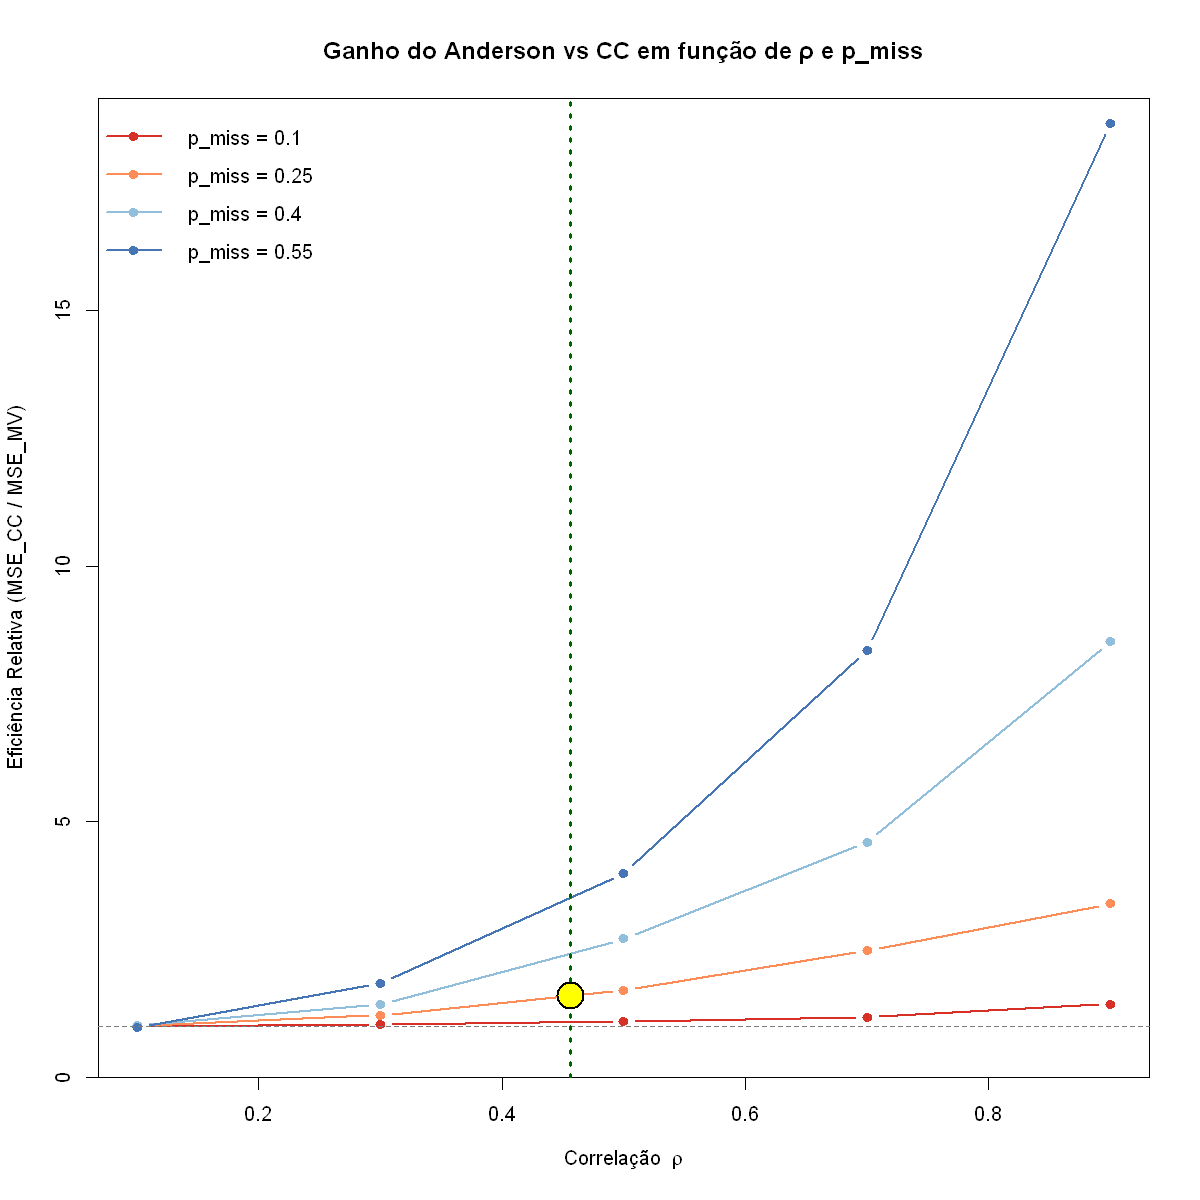

In [837]:
# =========================
# Dados reais
# =========================

completo <- !is.na(airquality$Solar.R) & !is.na(airquality$logOzone)
y1_obs   <- !is.na(airquality$Solar.R)

rho_real <- cor(
  airquality$Solar.R[completo],
  airquality$logOzone[completo]
)

p_miss_real <- sum(!completo & y1_obs) / sum(y1_obs)

cat(sprintf("rho    = %.3f\n", rho_real))
cat(sprintf("p_miss = %.3f\n", p_miss_real))

# =========================
# Eficiência esperada para os dados reais
# =========================

# curva de p_miss mais próxima
idx_p <- which.min(abs(p_misss - p_miss_real))

# eficiência interpolada no rho observado
ef_real <- approx(
  x    = rhos,
  y    = mat_ef[, idx_p],
  xout = rho_real,
  rule = 2
)$y

# =========================
# Gráfico
# =========================

par(bg = "white")

cores_p <- c("#d73027", "#fc8d59", "#91bfdb", "#4575b4")

matplot(
  rhos,
  mat_ef,
  type = "b",
  pch = 19,
  lwd = 2,
  lty = 1,
  col = cores_p,
  xlab = expression("Correlação " ~ rho),
  ylab = "Eficiência Relativa (MSE_CC / MSE_MV)",
  main = "Ganho do Anderson vs CC em função de ρ e p_miss",
  ylim = c(0, max(mat_ef, na.rm = TRUE) + 0.5),
  yaxs = "i"
)

abline(h = 0, col = "black", lwd = 1)
abline(h = 1, lty = 2, col = "gray50")

legend(
  "topleft",
  legend = paste0("p_miss = ", p_misss),
  col = cores_p,
  lwd = 2,
  pch = 19,
  bty = "n"
)

# =========================
# Destaque dos dados reais
# =========================

# linha vertical no rho observado
abline(
  v = rho_real,
  col = "darkgreen",
  lwd = 3,
  lty = 3
)

# ponto destacado
points(
  rho_real,
  ef_real,
  pch = 21,
  bg = "yellow",
  col = "black",
  cex = 3,
  lwd = 2
)

Como é possível ver no heatmap, o estimador de Anderson se sobressai conforme os dados estão mais correlacionados e a fração de dados faltantes é maior! Porém, olhando para o nosso cenário real (ponto amarelo na imagem), o ganho do estimador de Anderson ainda se sobressai, mas porque nossos intervalos deram tão parecidos? Isso na verdade é **esperado**! Vamos olhar as fórmulas dos intervalos de confiança de cada um dos estimadores:

### Casos Completos (CC)
O intervalo de confiança de nível $1-\alpha$ é dado por
$$
    \text{IC}_{(1-\alpha)}(\mu_{y, \text{CC}}) = \left[ \overline{y}^{*} - t_{\alpha/2, \, n-1} \frac{\hat{\sigma}_{y,*}}{\sqrt{n-1}} \quad , \quad \overline{y}^{*} + t_{\alpha/2, \, n-1} \frac{\hat{\sigma}_{y,*}}{\sqrt{n-1}} \right]
$$

$$
    \hat{\sigma}_{y,*} = \sqrt{\frac{1}{n}\sum_{\alpha=1}^{n}(y_{\alpha}-\overline{y}^{*})^2}
$$

### Anderson
O intervalo de confiança assintótico para a média com nível de confiança $1 - \alpha$
$$
    \text{IC}_{(1-\alpha)}(\mu_{y, \text{Anderson}}) = \left[ \hat{\mu}_{y, \text{Anderson}} - z_{\alpha/2} \cdot \text{SE}(\hat{\mu}_{y}) \quad , \quad \hat{\mu}_{y, \text{Anderson}} + z_{\alpha/2} \cdot \text{SE}(\hat{\mu}_{y}) \right]
$$

$$
    \text{SE}(\hat{\mu}_{y}) = \sqrt{ \frac{\hat{\sigma}_{y,*}^2 (1 - \hat{\rho}^2)}{n} \left( 1 + \frac{(\overline{x} - \overline{x}^{*})^2}{\hat{\sigma}_{x,*}^2} \right) + \frac{\hat{\beta}_{yx}^2 \hat{\sigma}_x^2}{n + r} }
$$

perceba que, nos estimadores de CC, eles não dependem de nenhuma informação de $x$, ao contrário do estimador de Anderson, e o ponto principal aqui é a dependência do intervalo em $\sigma^2_x$! Nos códigos anteriores, nós fizemos todas essas estimativas, e vimos que a variância de $Y_1$ era muito alta! Então esse é o ponto chave do porquê os intervalos estão parecidos, não é que o estimador de Anderson esteja se saindo pior em nosso caso, mas a alta variância dos dados $Y_1$ faz com que o estimador perca certeza, consequentemente aumentando seu intervalo de confiança e o tornando parecido com o de $\ln Y_2$